# Lorenz-63 Parameter Estimation

See Chapter 1, Section 1.1: Bayesian Inversion; Chapter 1, Section 1.2.1: Maximum A Posteriori Estimator; Chapter 6, Section 6.3.5: Ensemble Kalman Filter; Chapter 15, Section 15.5: Markov Chain Monte Carlo.

This demo studies the inverse problem of estimating the Lorenz-63 parameters $\theta=(\sigma,\rho)$ from a noisy partial observation trajectory. The physical state $v=(x,y,z)^\top$ follows
$$
\begin{aligned}
\dot x &= \sigma(y-x), \\
\dot y &= x(\rho-z)-y, \\
\dot z &= xy-\beta z.
\end{aligned}
$$
The standard chaotic truth is $\theta^\dagger=(\sigma^\dagger,\rho^\dagger)=(10,28)$ with fixed $\beta=8/3$. Observations are restricted to the first state component:
$$
Y^\dagger_J = \{y^\dagger_1,\ldots,y^\dagger_J\}, \qquad
y^\dagger_j = H v(t_j;\theta^\dagger) + \eta_j,\qquad
H v = x,\qquad \eta_j\sim \mathcal{N}(0,\sigma_{\rm obs}^2).
$$
The prior is a biased Gaussian,
$$
\theta \sim \mathcal{N}\left(
\begin{bmatrix}9.0\\30.0\end{bmatrix},
\begin{bmatrix}4.0&0\\0&9.0\end{bmatrix}
\right).
$$
Under the deterministic model, the likelihood is available by integrating the ODE:
$$
p(Y^\dagger_J\mid \theta)\propto
\exp\left(
-\frac{1}{2\sigma_{\rm obs}^2}
\sum_{j=1}^{J}\|y^\dagger_j-Hv(t_j;\theta)\|^2
\right).
$$

The MAP estimator minimizes the negative log-posterior objective
$$
J(\theta)=
\underbrace{\frac{1}{2\sigma_{\rm obs}^2}\sum_{j=1}^{J}\|y^\dagger_j-Hv(t_j;\theta)\|^2}_{\mathcal{L}_{\rm data}(\theta)}
+
\underbrace{\frac{1}{2}(\theta-\mu_{\rm prior})^\top\Sigma_{\rm prior}^{-1}(\theta-\mu_{\rm prior})}_{\mathcal{L}_{\rm reg}(\theta)},
$$
so that
$$
\hat{\theta}_{\rm MAP}=\operatorname*{argmin}_{\theta}J(\theta).
$$
The Laplace approximation turns this point estimate into a local Gaussian approximation:
$$
p(\theta\mid Y^\dagger_J)\approx\mathcal{N}(\hat{\theta}_{\rm MAP},\Sigma_{\rm post}),\qquad
\Sigma_{\rm post}\approx\left(\nabla^2J(\hat{\theta}_{\rm MAP})\right)^{-1}.
$$

The same inverse problem can also be attacked sequentially using state augmentation. Define
$$
u_j=[v_j,\theta_j]^\top=[x_j,y_j,z_j,\sigma_j,\rho_j]^\top\in\mathbb{R}^5.
$$
The augmented forecast combines the RK4 state solver with a small random walk in parameter space:
$$
\begin{aligned}
v_{k+1} &= {\rm RK4}(v_k,\theta_k,\Delta t),\\
\theta_{k+1} &= \theta_k+\xi_k,\qquad \xi_k\sim\mathcal{N}(0,\Sigma_{\rm jitter}).
\end{aligned}
$$
Updating the whole augmented ensemble with observations of only $x$ allows cross-covariances to move the unobserved parameter dimensions.


**Parameter exploration.**

- Adjust `obs_count` to see how additional observations sharpen the posterior and reduce the disagreement between MCMC, MAP-Laplace, and augmented EnKF.
- Increase `observation_noise` to make the likelihood less informative; the prior and the EnKF ensemble spread then become visibly more important.
- Compare `enkf_ensemble_size` and `parameter_jitter`: too small an ensemble or too little jitter can collapse the parameter cloud before it has tracked the data.
- Toggle `force_retrain` only when you want to ignore an existing checkpoint and recompute all iterative results with the displayed settings.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `obs_count` | `observation_noise` | `enkf_ensemble_size` | `parameter_jitter` | Purpose |
|---:|---:|---:|---:|---|
| 25 | 1.0 | 160 | 0.015 | A visibly broad posterior with limited data. |
| 35 | 1.0 | 160 | 0.015 | A balanced default where all three methods can be compared. |
| 50 | 2.0 | 160 | 0.025 | A noisier case where uncertainty and filter spread matter. |
| 50 | 1.0 | 60 | 0.000 | A collapse-prone augmented EnKF case. |


Loaded checkpoint: checkpoints/lorenz63_parameter_estimation/combined_methods/ebc181849398.pkl
MCMC acceptance rate: 0.528
MAP estimate: sigma=10.051, rho=27.966
EnKF final mean: sigma=9.340, rho=28.898
Energy distance to MCMC reference: Laplace=0.001, augmented EnKF=1.208


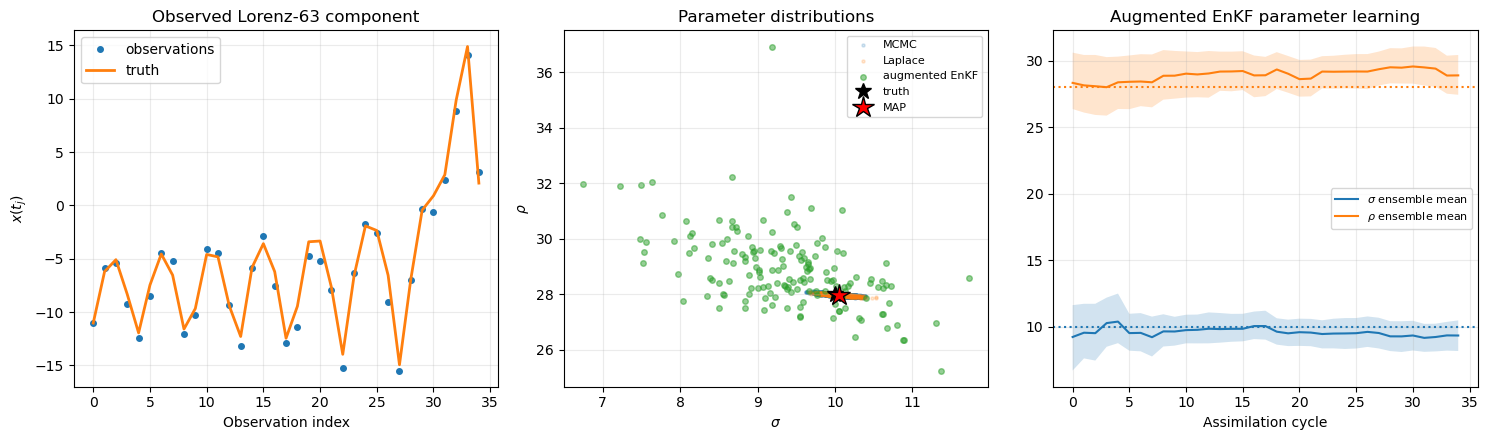

In [1]:
#@title Lorenz-63 Parameter Estimation
import hashlib
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.special import logsumexp

DEFAULTS = {
    "true_sigma": 10.0,
    "true_rho": 28.0,
    "beta": 8.0 / 3.0,
    "dt": 0.03,
    "obs_interval_steps": 5,
    "obs_count": 35,
    "observation_noise": 1.0,
    "prior_mu_sigma": 9.0,
    "prior_std_sigma": 2.0,
    "prior_mu_rho": 30.0,
    "prior_std_rho": 3.0,
    "mcmc_samples": 5000,
    "mcmc_burn_in": 1250,
    "mcmc_step_sigma": 0.035,
    "mcmc_step_rho": 0.035,
    "enkf_ensemble_size": 160,
    "parameter_jitter": 0.015,
    "inflation": 1.02,
    "random_seed": 7,
    "force_retrain": False,
}

use_default = False #@param {type:"boolean"}
obs_count = 35 #@param {type:"slider", min:20, max:100, step:5}
observation_noise = 1.0 #@param {type:"slider", min:0.5, max:2.5, step:0.25}
mcmc_samples = 5000 #@param {type:"slider", min:1000, max:12000, step:1000}
enkf_ensemble_size = 160 #@param {type:"slider", min:40, max:400, step:20}
parameter_jitter = 0.015 #@param {type:"slider", min:0.0, max:0.06, step:0.005}
force_retrain = False #@param {type:"boolean"}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "obs_count": int(obs_count),
        "observation_noise": float(observation_noise),
        "mcmc_samples": int(mcmc_samples),
        "enkf_ensemble_size": int(enkf_ensemble_size),
        "parameter_jitter": float(parameter_jitter),
        "force_retrain": bool(force_retrain),
    })


def checkpoint_path(method_name, params):
    cache_params = {k: v for k, v in params.items() if k != "force_retrain"}
    key = hashlib.sha256(json.dumps(cache_params, sort_keys=True).encode()).hexdigest()[:12]
    path = Path("checkpoints") / "lorenz63_parameter_estimation" / method_name
    path.mkdir(parents=True, exist_ok=True)
    return path / f"{key}.pkl"


def save_checkpoint(path, payload):
    with open(path, "wb") as f:
        pickle.dump(payload, f)


def load_checkpoint(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def lorenz63_rhs(v, sigma, rho, beta):
    x, y, z = v
    return np.array([sigma * (y - x), x * (rho - z) - y, x * y - beta * z], dtype=float)


def rk4_step(v, sigma, rho, beta, dt):
    k1 = lorenz63_rhs(v, sigma, rho, beta)
    k2 = lorenz63_rhs(v + 0.5 * dt * k1, sigma, rho, beta)
    k3 = lorenz63_rhs(v + 0.5 * dt * k2, sigma, rho, beta)
    k4 = lorenz63_rhs(v + dt * k3, sigma, rho, beta)
    return v + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0


def simulate_lorenz63(theta, total_steps, dt, beta, x0):
    sigma, rho = theta
    states = np.empty((total_steps + 1, 3), dtype=float)
    states[0] = x0
    for k in range(total_steps):
        states[k + 1] = rk4_step(states[k], sigma, rho, beta, dt)
        if not np.all(np.isfinite(states[k + 1])) or np.linalg.norm(states[k + 1]) > 1e6:
            states[k + 1:] = np.nan
            break
    return states


def make_data(params):
    rng = np.random.default_rng(params["random_seed"])
    x0 = np.array([1.0, 1.0, 1.0])
    burn = 300
    burn_traj = simulate_lorenz63(
        (params["true_sigma"], params["true_rho"]),
        burn,
        params["dt"],
        params["beta"],
        x0,
    )
    x0 = burn_traj[-1]
    total_steps = params["obs_count"] * params["obs_interval_steps"]
    truth = simulate_lorenz63(
        (params["true_sigma"], params["true_rho"]),
        total_steps,
        params["dt"],
        params["beta"],
        x0,
    )
    obs_idx = np.arange(params["obs_interval_steps"], total_steps + 1, params["obs_interval_steps"])
    clean = truth[obs_idx, 0]
    y_obs = clean + params["observation_noise"] * rng.normal(size=len(clean))
    return x0, truth, obs_idx, y_obs


def log_posterior(theta, x0, obs_idx, y_obs, params):
    sigma, rho = theta
    if not (0.1 < sigma < 50.0 and 0.1 < rho < 80.0):
        return -np.inf
    traj = simulate_lorenz63(theta, int(obs_idx[-1]), params["dt"], params["beta"], x0)
    y_model = traj[obs_idx, 0]
    if not np.all(np.isfinite(y_model)):
        return -np.inf
    s2 = params["observation_noise"] ** 2
    ll = -0.5 * np.sum((y_obs - y_model) ** 2) / s2
    lp = -0.5 * ((sigma - params["prior_mu_sigma"]) / params["prior_std_sigma"]) ** 2
    lp += -0.5 * ((rho - params["prior_mu_rho"]) / params["prior_std_rho"]) ** 2
    return ll + lp


def coarse_grid_mode(x0, obs_idx, y_obs, params):
    sigmas = np.linspace(6.5, 14.0, 31)
    rhos = np.linspace(22.0, 34.0, 31)
    logp = np.empty((len(sigmas), len(rhos)))
    for i, sigma in enumerate(sigmas):
        for j, rho in enumerate(rhos):
            logp[i, j] = log_posterior((sigma, rho), x0, obs_idx, y_obs, params)
    loc = np.unravel_index(np.nanargmax(logp), logp.shape)
    return np.array([sigmas[loc[0]], rhos[loc[1]]], dtype=float), logp, sigmas, rhos


def run_mcmc(x0, obs_idx, y_obs, params):
    rng = np.random.default_rng(params["random_seed"] + 10)
    chain = np.empty((params["mcmc_samples"], 2), dtype=float)
    current, _, _, _ = coarse_grid_mode(x0, obs_idx, y_obs, params)
    current_lp = log_posterior(current, x0, obs_idx, y_obs, params)
    prop_scale = np.array([params["mcmc_step_sigma"], params["mcmc_step_rho"]])
    accepted = 0
    for i in range(params["mcmc_samples"]):
        proposal = current + prop_scale * rng.normal(size=2)
        proposal_lp = log_posterior(proposal, x0, obs_idx, y_obs, params)
        if np.log(rng.uniform()) < proposal_lp - current_lp:
            current, current_lp = proposal, proposal_lp
            accepted += 1
        chain[i] = current
    return {"chain": chain, "acceptance_rate": accepted / params["mcmc_samples"]}


def negative_log_posterior(theta, x0, obs_idx, y_obs, params):
    lp = log_posterior(theta, x0, obs_idx, y_obs, params)
    return np.inf if not np.isfinite(lp) else -lp


def finite_difference_hessian(fun, theta, eps=1e-3):
    theta = np.asarray(theta, dtype=float)
    hess = np.zeros((len(theta), len(theta)))
    f0 = fun(theta)
    for i in range(len(theta)):
        ei = np.zeros_like(theta)
        ei[i] = eps
        hess[i, i] = (fun(theta + ei) - 2 * f0 + fun(theta - ei)) / eps**2
        for j in range(i + 1, len(theta)):
            ej = np.zeros_like(theta)
            ej[j] = eps
            hess[i, j] = (
                fun(theta + ei + ej)
                - fun(theta + ei - ej)
                - fun(theta - ei + ej)
                + fun(theta - ei - ej)
            ) / (4 * eps**2)
            hess[j, i] = hess[i, j]
    return hess


def run_map_laplace(x0, obs_idx, y_obs, params):
    grid_start, _, _, _ = coarse_grid_mode(x0, obs_idx, y_obs, params)
    starts = [
        grid_start,
        np.array([params["prior_mu_sigma"], params["prior_mu_rho"]], dtype=float),
        np.array([11.0, 27.0], dtype=float),
    ]
    bounds = [(2.0, 20.0), (10.0, 45.0)]
    obj = lambda th: negative_log_posterior(th, x0, obs_idx, y_obs, params)
    candidates = [
        minimize(obj, start, method="L-BFGS-B", bounds=bounds, options={"maxiter": 120})
        for start in starts
    ]
    opt = min(candidates, key=lambda result: result.fun)
    hess = finite_difference_hessian(obj, opt.x)
    hess = 0.5 * (hess + hess.T)
    evals, evecs = np.linalg.eigh(hess)
    evals = np.maximum(evals, 1e-6)
    cov = evecs @ np.diag(1.0 / evals) @ evecs.T
    rng = np.random.default_rng(params["random_seed"] + 20)
    laplace_samples = rng.multivariate_normal(opt.x, cov, size=1500)
    return {"map": opt.x, "cov": cov, "samples": laplace_samples, "success": bool(opt.success)}


def run_augmented_enkf(x0, obs_idx, y_obs, params):
    rng = np.random.default_rng(params["random_seed"] + 30)
    n = params["enkf_ensemble_size"]
    ensemble = np.zeros((n, 5), dtype=float)
    ensemble[:, :3] = x0 + 0.1 * rng.normal(size=(n, 3))
    ensemble[:, 3] = params["prior_mu_sigma"] + params["prior_std_sigma"] * rng.normal(size=n)
    ensemble[:, 4] = params["prior_mu_rho"] + params["prior_std_rho"] * rng.normal(size=n)
    history = []
    last_idx = 0
    r_var = params["observation_noise"] ** 2
    for j, idx in enumerate(obs_idx):
        steps = int(idx - last_idx)
        last_idx = int(idx)
        for _ in range(steps):
            for i in range(n):
                ensemble[i, :3] = rk4_step(
                    ensemble[i, :3],
                    ensemble[i, 3],
                    ensemble[i, 4],
                    params["beta"],
                    params["dt"],
                )
            ensemble[:, 3:5] += params["parameter_jitter"] * rng.normal(size=(n, 2))
        mean = ensemble.mean(axis=0)
        anomalies = ensemble - mean
        h = ensemble[:, 0]
        h_anom = h - h.mean()
        cov_xh = anomalies.T @ h_anom / (n - 1)
        var_h = h_anom @ h_anom / (n - 1) + r_var
        kalman_gain = cov_xh / var_h
        perturbed_obs = y_obs[j] + params["observation_noise"] * rng.normal(size=n)
        ensemble = ensemble + (perturbed_obs - h)[:, None] * kalman_gain[None, :]
        mean = ensemble.mean(axis=0)
        ensemble = mean + params["inflation"] * (ensemble - mean)
        ensemble[:, 3:5] = np.clip(ensemble[:, 3:5], [0.1, 0.1], [50.0, 80.0])
        history.append(ensemble.copy())
    return {"final_ensemble": ensemble, "history": np.array(history)}


def energy_distance(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    ab = np.linalg.norm(a[:, None, :] - b[None, :, :], axis=-1).mean()
    aa = np.linalg.norm(a[:, None, :] - a[None, :, :], axis=-1).mean()
    bb = np.linalg.norm(b[:, None, :] - b[None, :, :], axis=-1).mean()
    return 2 * ab - aa - bb


x0, truth, obs_idx, y_obs = make_data(params)
ckpt = checkpoint_path("combined_methods", params)
if ckpt.exists() and not params["force_retrain"]:
    payload = load_checkpoint(ckpt)
    print(f"Loaded checkpoint: {ckpt}")
else:
    mcmc = run_mcmc(x0, obs_idx, y_obs, params)
    map_laplace = run_map_laplace(x0, obs_idx, y_obs, params)
    enkf = run_augmented_enkf(x0, obs_idx, y_obs, params)
    payload = {"mcmc": mcmc, "map_laplace": map_laplace, "enkf": enkf}
    save_checkpoint(ckpt, payload)
    print(f"Saved checkpoint: {ckpt}")

chain = payload["mcmc"]["chain"]
posterior = chain[params["mcmc_burn_in"]:]
laplace_samples = payload["map_laplace"]["samples"]
enkf_params = payload["enkf"]["final_ensemble"][:, 3:5]
ed_enkf = energy_distance(enkf_params, posterior[:: max(1, len(posterior) // len(enkf_params))][: len(enkf_params)])
ed_laplace = energy_distance(laplace_samples[:1000], posterior[:: max(1, len(posterior) // 1000)][:1000])

print(f"MCMC acceptance rate: {payload['mcmc']['acceptance_rate']:.3f}")
print(f"MAP estimate: sigma={payload['map_laplace']['map'][0]:.3f}, rho={payload['map_laplace']['map'][1]:.3f}")
print(f"EnKF final mean: sigma={enkf_params[:,0].mean():.3f}, rho={enkf_params[:,1].mean():.3f}")
print(f"Energy distance to MCMC reference: Laplace={ed_laplace:.3f}, augmented EnKF={ed_enkf:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(np.arange(len(y_obs)), y_obs, "o", ms=4, label="observations")
axes[0].plot(np.arange(len(y_obs)), truth[obs_idx, 0], "-", lw=2, label="truth")
axes[0].set_title("Observed Lorenz-63 component")
axes[0].set_xlabel("Observation index")
axes[0].set_ylabel("$x(t_j)$")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].scatter(posterior[:, 0], posterior[:, 1], s=5, alpha=0.18, label="MCMC")
axes[1].scatter(laplace_samples[:800, 0], laplace_samples[:800, 1], s=5, alpha=0.18, label="Laplace")
axes[1].scatter(enkf_params[:, 0], enkf_params[:, 1], s=16, alpha=0.5, label="augmented EnKF")
axes[1].plot(params["true_sigma"], params["true_rho"], "k*", ms=12, label="truth")
axes[1].plot(payload["map_laplace"]["map"][0], payload["map_laplace"]["map"][1], marker="*", color="red", markeredgecolor="black", markersize=16, linestyle="None", label="MAP")
axes[1].set_title("Parameter distributions")
axes[1].set_xlabel("$\\sigma$")
axes[1].set_ylabel("$\\rho$")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

hist = payload["enkf"]["history"][:, :, 3:5]
axes[2].plot(hist[:, :, 0].mean(axis=1), label="$\\sigma$ ensemble mean")
axes[2].fill_between(np.arange(len(hist)), np.percentile(hist[:, :, 0], 10, axis=1), np.percentile(hist[:, :, 0], 90, axis=1), alpha=0.2)
axes[2].plot(hist[:, :, 1].mean(axis=1), label="$\\rho$ ensemble mean")
axes[2].fill_between(np.arange(len(hist)), np.percentile(hist[:, :, 1], 10, axis=1), np.percentile(hist[:, :, 1], 90, axis=1), alpha=0.2)
axes[2].axhline(params["true_sigma"], color="C0", ls=":")
axes[2].axhline(params["true_rho"], color="C1", ls=":")
axes[2].set_title("Augmented EnKF parameter learning")
axes[2].set_xlabel("Assimilation cycle")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
